In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"D:\CreditIQ\data\application_clean.csv")
print(f"Loaded: {df.shape}")

# Separate features and target
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Loaded: (307511, 90)
Features: 88
Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [3]:
# Identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

print(f"Categorical: {len(cat_cols)} → {cat_cols}")
print(f"Numerical: {len(num_cols)}")

Categorical: 12 → ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']
Numerical: 76


In [4]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

In [5]:
# Model 1: Logistic Regression (baseline)
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Stratified 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_scores = cross_val_score(lr_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"Logistic Regression AUC-ROC: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")

Logistic Regression AUC-ROC: 0.7490 (+/- 0.0045)


In [6]:
# Model 2: Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200, max_depth=12, 
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

rf_scores = cross_val_score(rf_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"Random Forest AUC-ROC: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")

Random Forest AUC-ROC: 0.7482 (+/- 0.0046)


In [7]:
from xgboost import XGBClassifier

# Model 3: XGBoost
scale_pos_weight = len(y[y==0]) / len(y[y==1])  # handles imbalance

xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, eval_metric='auc'
    ))
])

xgb_scores = cross_val_score(xgb_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"XGBoost AUC-ROC: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")

XGBoost AUC-ROC: 0.7630 (+/- 0.0045)


In [8]:
from lightgbm import LGBMClassifier

# Model 4: LightGBM
lgbm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        is_unbalance=True,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    ))
])

lgbm_scores = cross_val_score(lgbm_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"LightGBM AUC-ROC: {lgbm_scores.mean():.4f} (+/- {lgbm_scores.std():.4f})")

LightGBM AUC-ROC: 0.7635 (+/- 0.0039)


In [9]:
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"Logistic Regression: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")
print(f"Random Forest:       {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
print(f"XGBoost:             {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")
print(f"LightGBM:            {lgbm_scores.mean():.4f} (+/- {lgbm_scores.std():.4f})")

MODEL COMPARISON
Logistic Regression: 0.7490 (+/- 0.0045)
Random Forest:       0.7482 (+/- 0.0046)
XGBoost:             0.7630 (+/- 0.0045)
LightGBM:            0.7635 (+/- 0.0039)


In [10]:
param_dist = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [4, 6, 8, 10],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.6, 0.7, 0.8],
    'model__min_child_samples': [20, 50, 100],
    'model__reg_alpha': [0, 0.1, 1.0],
    'model__reg_lambda': [0, 0.1, 1.0]
}

search = RandomizedSearchCV(
    lgbm_pipe, param_dist, n_iter=30, cv=cv,
    scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1
)

search.fit(X, y)
print(f"\nBest AUC-ROC: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best AUC-ROC: 0.7647
Best params: {'model__subsample': 0.9, 'model__reg_lambda': 0, 'model__reg_alpha': 0.1, 'model__n_estimators': 500, 'model__min_child_samples': 100, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}


AUC-ROC: 0.7664

              precision    recall  f1-score   support

           0       0.96      0.72      0.82     56538
           1       0.17      0.68      0.28      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.71      0.78     61503


Confusion Matrix:
[[40547 15991]
 [ 1586  3379]]


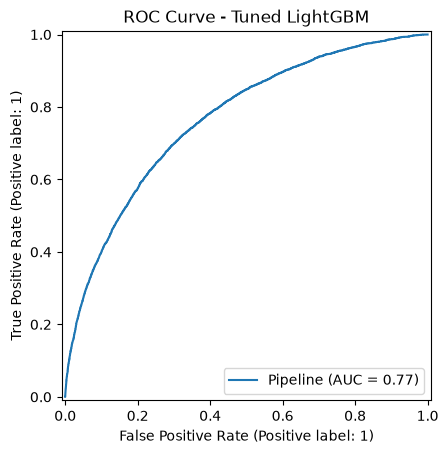

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt

# Train final model on train set, evaluate on held-out test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

best_model = search.best_estimator_
best_model.fit(X_train, y_train)

# Predict probabilities
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

# Metrics
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

# ROC Curve
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title('ROC Curve - Tuned LightGBM')
plt.show()

In [14]:
import joblib

# Save model
joblib.dump(best_model, r"D:\CreditIQ\model\best_lgbm_pipeline.pkl")

# Save feature names for later use
feature_names = num_cols + cat_cols
joblib.dump(feature_names, r"D:\CreditIQ\model\feature_names.pkl")

print("Model saved!")

Model saved!


In [15]:
import shap

# Get the preprocessed test data
X_test_processed = best_model.named_steps['preprocessor'].transform(X_test)

# Get feature names after preprocessing
feature_names = num_cols + cat_cols

# SHAP explainer on the model's LightGBM component
explainer = shap.TreeExplainer(best_model.named_steps['model'])
shap_values = explainer.shap_values(X_test_processed)

# If shap_values is a list (binary classification), take class 1 (default)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (61503, 88)


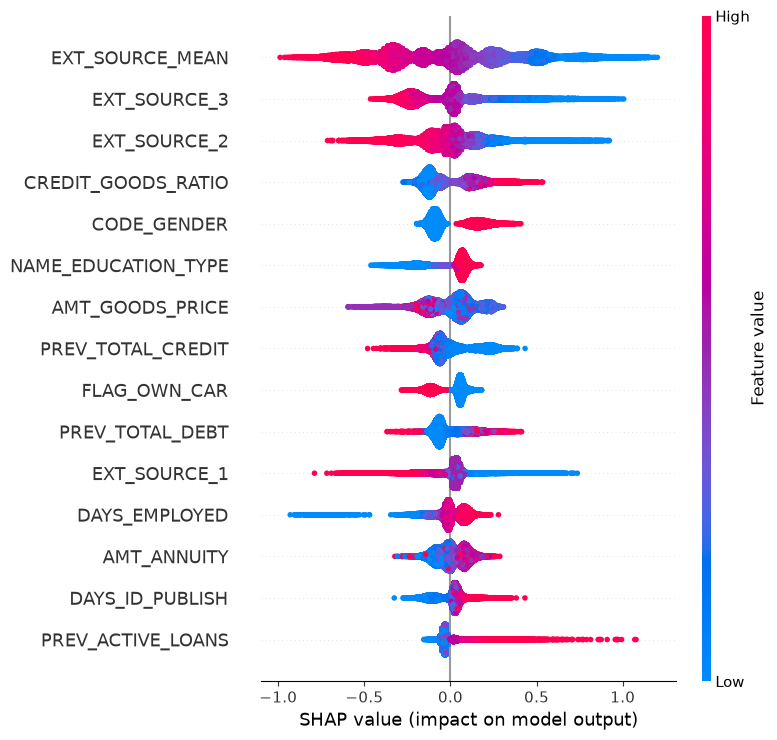

In [16]:
# Global feature importance — which features matter most overall
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names, max_display=15)

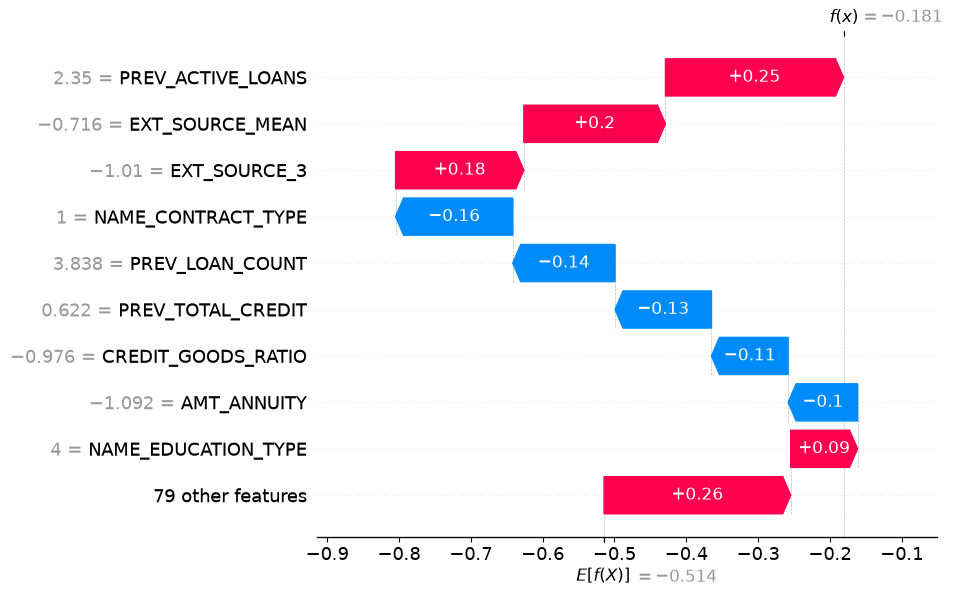

In [17]:
# Explain a single prediction — pick a defaulter from test set
defaulter_idx = y_test[y_test == 1].index[0]
idx_in_test = list(y_test.index).index(defaulter_idx)

shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx_in_test],
    base_values=explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
    data=X_test_processed[idx_in_test],
    feature_names=feature_names
))

In [18]:
# Run in notebook quickly
import joblib
model = joblib.load(r"D:\CreditIQ\model\best_lgbm_pipeline.pkl")
print("Model loaded successfully")
print(type(model))

Model loaded successfully
<class 'sklearn.pipeline.Pipeline'>
